In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
import math
from scipy.stats import ks_2samp

In [19]:
file = '/Users/jacob/Documents/Hawaii Research Project/master_files/master_file.fits'
hdul = fits.open(file)
data = hdul[1].data

dimm_values = data['dimm_value']
mass_values = data['mass_value']
ground_layer_values = data['seeing_gl']

In [3]:
def cdf_even_odd(data, title):

    # Flatten and clean data
    flattened_data_even = data[::2][np.isfinite(data[::2])].flatten()
    flattened_data_odd = data[::1][np.isfinite(data[::1])].flatten()
    
    n_even = len(flattened_data_even)
    n_odd = len(flattened_data_odd)

    # Calculate sample skewness
    data_skewness_even = skew(flattened_data_even)
    data_skewness_odd = skew(flattened_data_odd)

    # Calculate standard error of skewness
    sigma_g1_even = np.sqrt(6*(n_even-2) / ((n_even+1)*(n_even+3)))
    sigma_g1_odd = np.sqrt(6*(n_odd-2) / ((n_odd+1)*(n_odd+3)))

    # Calculate number of bins using Doane’s Rule
    k_even = int(np.ceil(1 + np.log2(n_even) + np.log2(1 + abs(data_skewness_even) / sigma_g1_even)))
    k_odd = int(np.ceil(1 + np.log2(n_odd) + np.log2(1 + abs(data_skewness_odd) / sigma_g1_odd)))

    # Compute histogram counts and bin edges
    counts_even, bin_edges_even = np.histogram(flattened_data_even, bins=k_even)
    counts_odd, bin_edges_odd = np.histogram(flattened_data_odd, bins=k_odd)
    
    bin_centers_even = (bin_edges_even[:-1] + bin_edges_even[1:]) / 2
    bin_centers_odd = (bin_edges_odd[:-1] + bin_edges_odd[1:]) / 2

    cdf_even = np.cumsum(counts_even)
    cdf_odd = np.cumsum(counts_odd)
    
    cdf_even = cdf_even / cdf_even[-1]
    cdf_odd = cdf_odd / cdf_odd[-1]

    # Perform KS test
    ks_stat, p_value = ks_2samp(flattened_data_even, flattened_data_odd)

    # Plot the CDFs 
    plt.figure(figsize=(6, 4))

    plt.plot(bin_centers_even, cdf_even, color='darkred', linewidth=4, linestyle='--', label='Even Values')
    plt.plot(bin_centers_odd, cdf_odd, color='lightblue', linewidth=2, label='Odd Values')

    plt.title(f'{title} Seeing CDF (Even vs. Odd Data)', fontsize = 14)
    plt.xlabel(f'{title} Seeing Value', fontsize = 12)
    plt.ylabel('Cumulative Probability', fontsize = 12)

    plt.ylim(0,1.05)

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'KS Test: D = {ks_stat:.3f}, p = {p_value:.3f}')

Using Doane's Rule for Number of Bins:


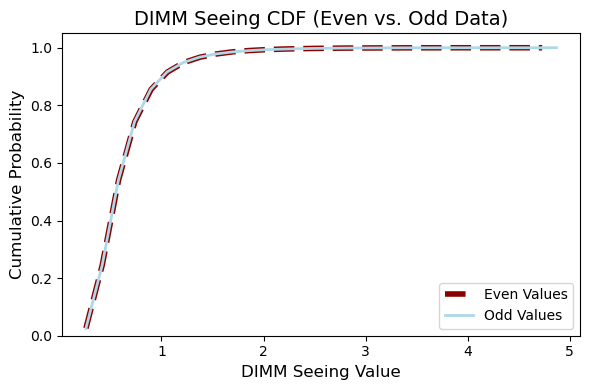

KS Test: D = 0.001, p = 1.000


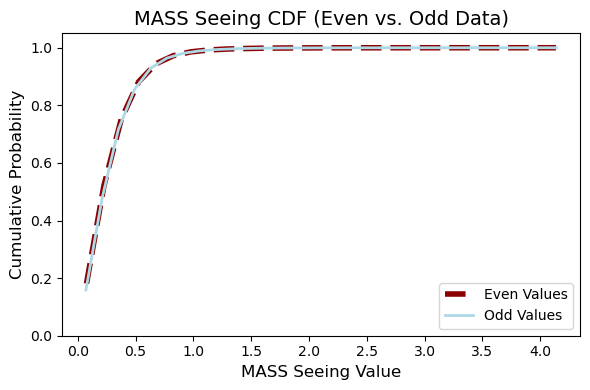

KS Test: D = 0.001, p = 0.949


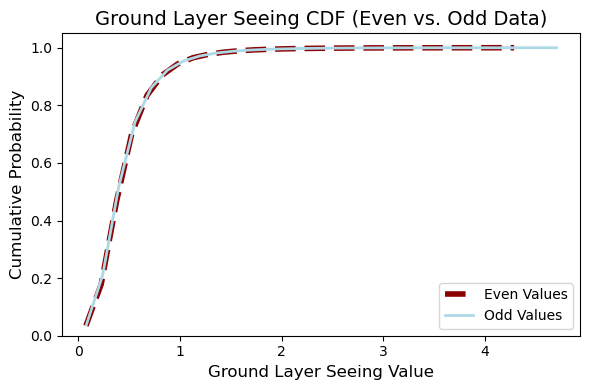

KS Test: D = 0.001, p = 1.000


In [4]:
print("Using Doane's Rule for Number of Bins:")
cdf_even_odd(dimm_values, 'DIMM')
cdf_even_odd(mass_values, 'MASS')
cdf_even_odd(ground_layer_values, 'Ground Layer')

In [11]:
def cdf_comparison(data1, data2):

    # Flatten and clean data
    flattened_data1 = data1[np.isfinite(data1)].flatten()
    flattened_data2 = data2[np.isfinite(data2)].flatten()
    
    n1 = len(flattened_data1)
    n2 = len(flattened_data2)

    # Calculate sample skewness
    data_skewness1 = skew(flattened_data1)
    data_skewness2 = skew(flattened_data2)

    # Calculate standard error of skewness
    sigma_g11 = np.sqrt(6*(n1-2) / ((n1+1)*(n1+3)))
    sigma_g12 = np.sqrt(6*(n2-2) / ((n2+1)*(n2+3)))

    # Calculate number of bins using Doane’s Rule
    k1 = int(np.ceil(1 + np.log2(n1) + np.log2(1 + abs(data_skewness1) / sigma_g11)))
    k2 = int(np.ceil(1 + np.log2(n2) + np.log2(1 + abs(data_skewness2) / sigma_g12)))

    # Compute histogram counts and bin edges
    counts1, bin_edges1 = np.histogram(flattened_data1, bins=k1)
    counts2, bin_edges2 = np.histogram(flattened_data2, bins=k2)
    
    bin_centers1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2
    bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2

    cdf1 = np.cumsum(counts1)
    cdf2 = np.cumsum(counts2)
    
    cdf1 = cdf1 / cdf1[-1]
    cdf2 = cdf2 / cdf2[-1]

    # Perform KS test
    ks_stat, p_value = ks_2samp(flattened_data1, flattened_data2)
    
    # Plot the CDFs
    plt.figure(figsize=(6, 4))

    plt.plot(bin_centers1, cdf1, color='darkred', linewidth=2, label='DIMM')
    plt.plot(bin_centers2, cdf2, color='darkblue', linewidth=2, label='MASS')

    plt.title('Comparison CDF (DIMM vs. MASS)', fontsize = 14)
    plt.xlabel('Seeing Value', fontsize = 12)
    plt.ylabel('Cumulative Probability', fontsize = 12)

    plt.ylim(0,1.05)

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'KS Test: D = {ks_stat:.3f}, p = {p_value:.3f}')

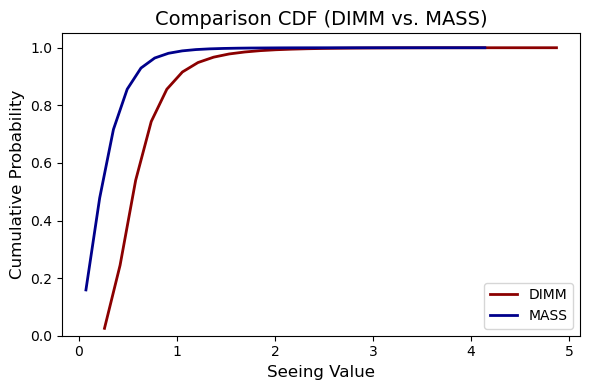

KS Test: D = 0.594, p = 0.000


In [12]:
cdf_comparison(dimm_values, mass_values)

In [22]:
def cdf_first_second_half(data, title):

    # Split, Flatten and clean data
    half = len(data) // 2
    flattened_data_first = data[:half][np.isfinite(data[:half])].flatten()
    flattened_data_second = data[half:][np.isfinite(data[half:])].flatten()
    
    n_first = len(flattened_data_first)
    n_second = len(flattened_data_second)

    # Calculate sample skewness
    data_skewness_first = skew(flattened_data_first)
    data_skewness_second = skew(flattened_data_second)

    # Calculate standard error of skewness
    sigma_g1_first = np.sqrt(6*(n_first-2) / ((n_first+1)*(n_first+3)))
    sigma_g1_second = np.sqrt(6*(n_second-2) / ((n_second+1)*(n_second+3)))

    # Calculate number of bins using Doane’s Rule
    k_first = int(np.ceil(1 + np.log2(n_first) + np.log2(1 + abs(data_skewness_first) / sigma_g1_first)))
    k_second = int(np.ceil(1 + np.log2(n_second) + np.log2(1 + abs(data_skewness_second) / sigma_g1_second)))

    # Compute histogram counts and bin edges
    counts_first, bin_edges_first = np.histogram(flattened_data_first, bins=k_first)
    counts_second, bin_edges_second = np.histogram(flattened_data_second, bins=k_second)
    
    bin_centers_first = (bin_edges_first[:-1] + bin_edges_first[1:]) / 2
    bin_centers_second = (bin_edges_second[:-1] + bin_edges_second[1:]) / 2

    cdf_first = np.cumsum(counts_first)
    cdf_second = np.cumsum(counts_second)
    
    cdf_first = cdf_first / cdf_first[-1]
    cdf_second = cdf_second / cdf_second[-1]

    # Perform KS test
    ks_stat, p_value = ks_2samp(flattened_data_first, flattened_data_second)

    # Plot the CDFs 
    plt.figure(figsize=(6, 4))

    plt.plot(bin_centers_first, cdf_first, color='darkred', linewidth=4, linestyle='--', label='1st Half of Data')
    plt.plot(bin_centers_second, cdf_second, color='lightblue', linewidth=2, label='2nd Half of Data')

    plt.title(f'{title} Seeing CDF (First vs. Second Half of Data)', fontsize = 14)
    plt.xlabel(f'{title} Seeing Value', fontsize = 12)
    plt.ylabel('Cumulative Probability', fontsize = 12)

    plt.ylim(0,1.05)

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'KS Test: D = {ks_stat:.3f}, p = {p_value:.3f}')

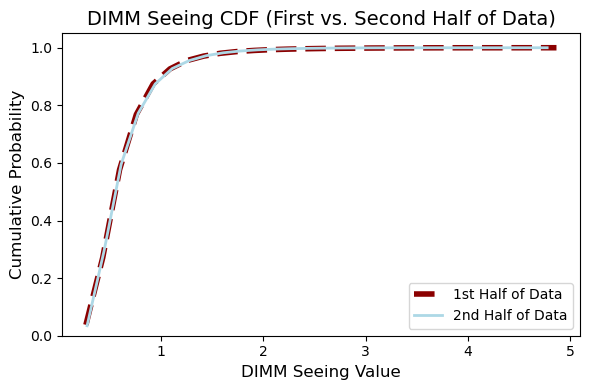

KS Test: D = 0.019, p = 0.000


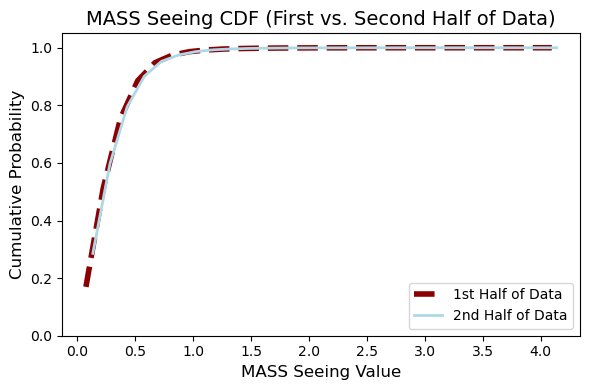

KS Test: D = 0.026, p = 0.000


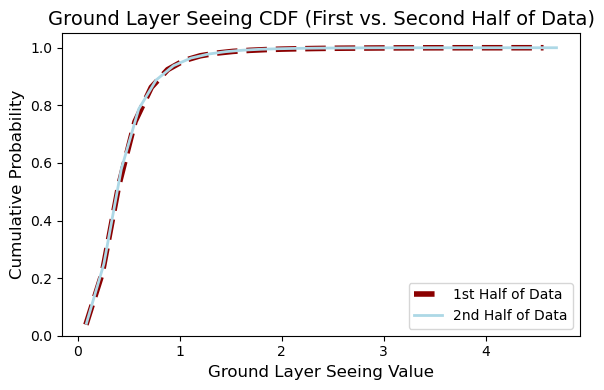

KS Test: D = 0.007, p = 0.000


In [23]:
cdf_first_second_half(dimm_values, "DIMM")
cdf_first_second_half(mass_values, "MASS")
cdf_first_second_half(ground_layer_values, "Ground Layer")